# Project GEO 876 - Visualizing wildfires interactively around the globe

#### By Javier Feller

# 1. Data loading

### 1.1 Importing packages

In [21]:
# data + geo
import pandas as pd
import geopandas as gpd
import numpy as np
import requests

# mapping
import folium
import contextily as cx
import cmcrameri.cm as cmc
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

### 1.2 Accessing API for (near) real-time fires

In [2]:
area_url='https://firms.modaps.eosdis.nasa.gov/api/area/csv/38064bff4711161d2878baf2b432ef5f/VIIRS_NOAA20_NRT/world/3'#3 at the end meaning data of last 3 days

response=requests.get(area_url)
# print(response.text) # no .json() to unpack required

#Check for handling potential errors
if response.status_code==200:
      print("Request worked")
else:
      print("Request did not work")

# Create dataframe and inspect data
df_area = pd.read_csv(area_url)
df_area

Request worked


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
0,19.39966,-155.27818,331.03,0.69,0.74,2026-05-20,33,N20,VIIRS,n,2.0NRT,299.11,11.65,D
1,19.40022,-155.27162,328.46,0.69,0.74,2026-05-20,33,N20,VIIRS,n,2.0NRT,295.17,11.93,D
2,19.40598,-155.28523,337.10,0.69,0.74,2026-05-20,33,N20,VIIRS,n,2.0NRT,304.95,13.45,D
3,19.40656,-155.27844,341.05,0.69,0.74,2026-05-20,33,N20,VIIRS,n,2.0NRT,303.85,13.45,D
4,19.40713,-155.27182,339.29,0.69,0.74,2026-05-20,33,N20,VIIRS,n,2.0NRT,301.47,28.34,D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62508,28.74498,-106.12020,298.82,0.40,0.40,2026-05-22,858,N20,VIIRS,n,2.1URT,285.81,0.60,N
62509,29.04023,-111.45436,319.69,0.50,0.40,2026-05-22,858,N20,VIIRS,n,2.1URT,290.30,2.18,N
62510,29.10753,-111.05888,299.45,0.50,0.40,2026-05-22,858,N20,VIIRS,n,2.1URT,288.70,0.49,N
62511,29.26492,-108.35878,295.70,0.40,0.40,2026-05-22,858,N20,VIIRS,n,2.1URT,284.85,0.61,N


### 1.3 Loading cities dataset for spatial analysis

In [3]:
worldcities_df=pd.read_csv(r"..\data\raw\worldcities.csv")

# 2. Data cleaning

### 2.1 Creating GeoDataFrame and inspecting data

In [4]:
wildfire_gdf=gpd.GeoDataFrame(df_area, geometry=gpd.points_from_xy(df_area["longitude"], df_area["latitude"]), crs=(4326))
print(wildfire_gdf.head(3))
print(wildfire_gdf.describe())
print(wildfire_gdf.crs)

   latitude  longitude  bright_ti4  scan  track    acq_date  acq_time  \
0  19.39966 -155.27818      331.03  0.69   0.74  2026-05-20        33   
1  19.40022 -155.27162      328.46  0.69   0.74  2026-05-20        33   
2  19.40598 -155.28523      337.10  0.69   0.74  2026-05-20        33   

  satellite instrument confidence version  bright_ti5    frp daynight  \
0       N20      VIIRS          n  2.0NRT      299.11  11.65        D   
1       N20      VIIRS          n  2.0NRT      295.17  11.93        D   
2       N20      VIIRS          n  2.0NRT      304.95  13.45        D   

                      geometry  
0  POINT (-155.27818 19.39966)  
1  POINT (-155.27162 19.40022)  
2  POINT (-155.28523 19.40598)  
           latitude     longitude    bright_ti4          scan         track  \
count  62513.000000  62513.000000  62513.000000  62513.000000  62513.000000   
mean      13.452011     36.397245    331.710874      0.455097      0.475994   
std       25.518328     76.802344     16.9264

### 2.2 Removing small wildfires & outliers

In [5]:
#Cut off extremes, differentiate between frp_raw for analysis, and frp_vis for visualization

wildfire_gdf = wildfire_gdf[wildfire_gdf["frp"] > 30].copy() #remove small wildfires under frp=30 

wildfire_gdf["frp_raw"] = wildfire_gdf["frp"]

upper = wildfire_gdf["frp"].quantile(0.99)

wildfire_gdf["frp_vis"] = wildfire_gdf["frp"].clip(upper=upper)

# 3. Spatial analysis

### 3.1 Mapping large cities - test

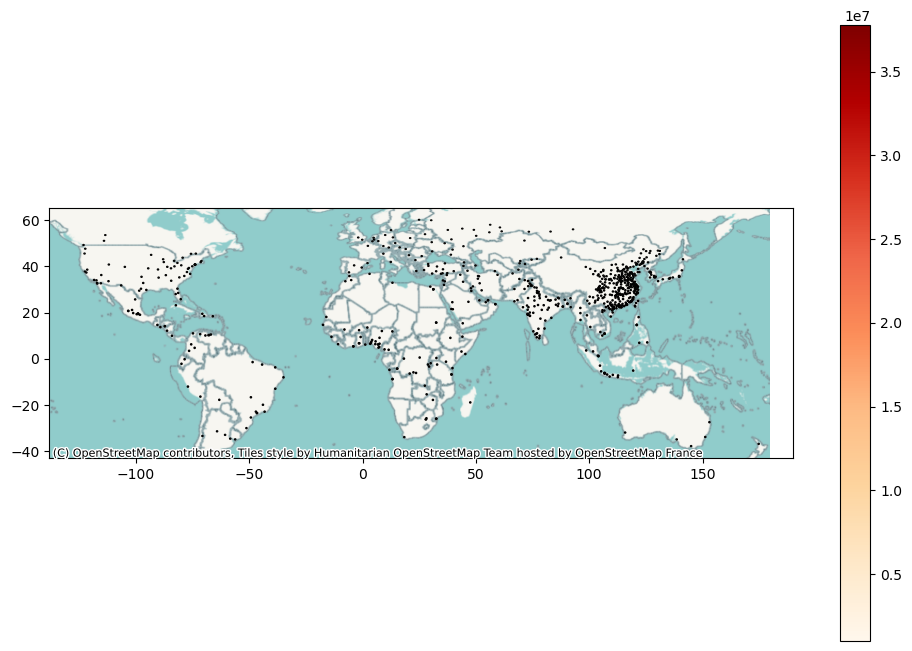

In [6]:
# Creating geodataframe
worldcities_gdf=gpd.GeoDataFrame(worldcities_df, geometry=gpd.points_from_xy(x=worldcities_df["lng"], y=worldcities_df["lat"]),  crs="4326")

# Selecting only cities with population larger than 1 Million
large_worldcities_gdf=worldcities_gdf[worldcities_gdf["population"] > 1000000]

# Changing projection to mercator, because WG84 is in degrees, not in meters. Then create buffer of 30km around cities.
large_worldcities_gdf=large_worldcities_gdf.to_crs(epsg=3857)
large_worldcities_gdf['geometry'] = large_worldcities_gdf.geometry.buffer(30000) #in meters

# Transforming back
large_worldcities_gdf = large_worldcities_gdf.to_crs(epsg=4326)

fig, ax=plt.subplots(figsize=(12, 8))

# plot
large_worldcities_gdf.plot(ax=ax,
    column="population",
    cmap="OrRd",
    legend=True,
    edgecolor="black"
)

cx.add_basemap(
    ax,
    crs="EPSG:4326"
)


### 3.2 Spatial join between wildfires and large cities

In [7]:
#spatial inner join

# set both geodataframes to same crs 
large_worldcities_gdf=large_worldcities_gdf.to_crs(epsg=4326)
wildfire_gdf=wildfire_gdf.to_crs(epsg=4326)

cities_fire_gdf=gpd.sjoin(wildfire_gdf, large_worldcities_gdf, how="inner", predicate="intersects")
cities_fire_gdf.head(3)

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,...,city_ascii,lat,lng,country,iso2,iso3,admin_name,capital,population,id
21456,14.13368,-87.36691,367.00,0.39,0.36,2026-05-20,1906,N20,VIIRS,h,...,Comayaguela,14.0980,-87.210,Honduras,HN,HND,Francisco Morazán,NaN,1250000.0,1340762485
21456,14.13368,-87.36691,367.00,0.39,0.36,2026-05-20,1906,N20,VIIRS,h,...,Tegucigalpa,14.1057,-87.204,Honduras,HN,HND,Francisco Morazán,primary,1157509.0,1340344059
50569,14.10944,-87.30614,341.95,0.40,0.44,2026-05-21,1847,N20,VIIRS,n,...,Comayaguela,14.0980,-87.210,Honduras,HN,HND,Francisco Morazán,NaN,1250000.0,1340762485


### 3.3 Automated early warning for cities

In [8]:
# Keeping only unique cities before looping
unique_cities = cities_fire_gdf.drop_duplicates(subset="city_ascii")

# iterate trough cities
for row in unique_cities.itertuples():
    print(
        f"Alert warning: The city of {row.city_ascii} "
        f"with a population of {row.population:,} is threatened by a proximate wildfire of less than 30 kilometers distance. Prepare for immediate evacuation."
    )

Alert warning: The city of Comayaguela with a population of 1,250,000.0 is threatened by a proximate wildfire of less than 30 kilometers distance. Prepare for immediate evacuation.
Alert warning: The city of Tegucigalpa with a population of 1,157,509.0 is threatened by a proximate wildfire of less than 30 kilometers distance. Prepare for immediate evacuation.


# 4. Visualization

## 4.1 Adding uncertainty as variable

In [9]:
wildfire_gdf["confidence"].unique()

wildfire_gdf["alpha"] = np.select(
    [
        wildfire_gdf["confidence"] == "h",
        wildfire_gdf["confidence"] == "n",
        wildfire_gdf["confidence"] == "l",
    ],
    [
        1.0,
        0.7,
        0.4
    ],
    default=0.5)

## 4.2 Creating static map (crs=3857)

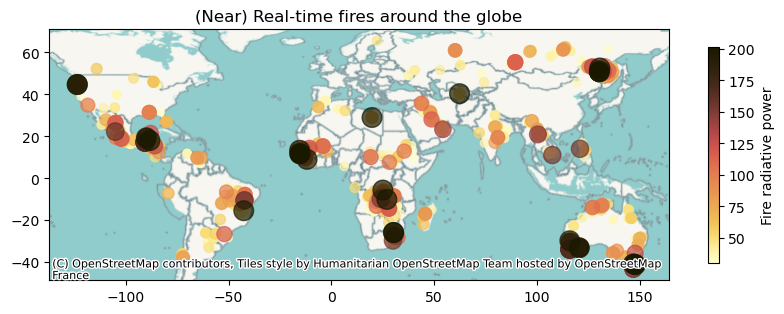

In [20]:
wildfire_gdf_sorted = wildfire_gdf.sort_values("frp_vis")

fig, ax = plt.subplots(figsize=(10, 4))

legend_options = {
    "label": "Fire radiative power",
    "orientation": "vertical",
    "shrink": 0.7
}

wildfire_gdf_sorted.plot(
    ax=ax,
    column="frp_vis",
    cmap="cmc.lajolla_r",
    markersize=wildfire_gdf_sorted["frp_vis"],  # FIXED
    alpha=0.7,
    legend=True,
    legend_kwds=legend_options
)

cx.add_basemap(ax=ax, crs=wildfire_gdf_sorted.crs)

plt.title("(Near) Real-time fires around the globe")

plt.show()

### 4.2.1 Add recentness of wildfire as variable

In [14]:
# Prepare Interactive map with recentness of events

# convert aqc_date and aqc_time to acq_datetime as datetime object
wildfire_gdf['acq_datetime'] = pd.to_datetime(wildfire_gdf['acq_date'] + ' ' + wildfire_gdf['acq_time'].astype(str).str.zfill(4), format='%Y-%m-%d %H%M')

# find maximum time from our dataset since we are pretending current date time is July 12 2023, 19:50(7:50pm) GMT.
# if the data were recent, we would set 
dt_max = pd.Timestamp.now();

# create our subsets for 4 color classes

# less than or equal to 1 hour; gdf1 <= 1hour
wildfire_gdf_12h = wildfire_gdf[wildfire_gdf['acq_datetime'] >= (dt_max - pd.Timedelta(hours=12))]

# greater than 1 hour but less than or equal to 24 hours; gdf2 > 1 hour and gdf2 <= 12 hours
wildfire_gdf_24h = wildfire_gdf[(wildfire_gdf['acq_datetime'] >= (dt_max - pd.Timedelta(hours=24))) & (wildfire_gdf['acq_datetime'] < (dt_max - pd.Timedelta(hours=12)))]

# greater than 1 hour but less than or equal to 24 hours; gdf2 > 1 hour and gdf2 <= 12 hours
wildfire_gdf_48h = wildfire_gdf[(wildfire_gdf['acq_datetime'] >= (dt_max - pd.Timedelta(hours=48))) & (wildfire_gdf['acq_datetime'] < (dt_max - pd.Timedelta(hours=24)))]

# greater than 24 hours; gdf4 > 12 hours
wildfire_gdf_more48h = wildfire_gdf[wildfire_gdf['acq_datetime'] < (dt_max - pd.Timedelta(hours=48))]

# convert once
g12 = wildfire_gdf_12h.to_crs(3857)
g24 = wildfire_gdf_24h.to_crs(3857)
g48 = wildfire_gdf_48h.to_crs(3857)
g48p = wildfire_gdf_more48h.to_crs(3857)

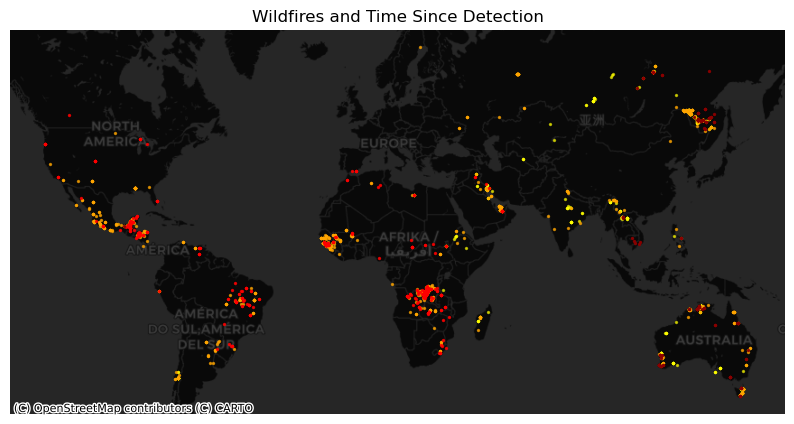

In [15]:
fig, ax = plt.subplots(figsize=(10, 10))

g48p.plot(ax=ax, color="yellow", markersize=2, alpha=0.6, zorder=1)
g48.plot(ax=ax, color="orange", markersize=2, alpha=0.7, zorder=2)
g24.plot(ax=ax, color="red", markersize=2, alpha=0.8, zorder=3)
g12.plot(ax=ax, color="darkred", markersize=2, alpha=0.9, zorder=4)

cx.add_basemap(ax, source=cx.providers.CartoDB.DarkMatter)

ax.set_title("Wildfires and Time Since Detection")
ax.set_axis_off()

plt.show()

### 4.2.3 Add large cities 

In [16]:
# cities threatened by proximate wildfire identified in spatial analysis

cities_fire_gdf

# Map (dark background)
m = folium.Map(
    location=[20, 0],
    zoom_start=2,
    tiles="CartoDB dark_matter",
    #control_scale=True
)

folium.TileLayer("OpenStreetMap", overlay=True).add_to(m)

folium.LayerControl(cities_fire_gdf).add_to(m)

## 4.3 Creating interactive map (final product)

### 4.3 Prepare for interactive map

In [17]:
# SORT (big fires last → on top)
# IMPORTANT: Folium needs EPSG:4326
wildfire_filtered = wildfire_gdf.to_crs(epsg=4326).sort_values(
    "frp_vis",
    ascending=True
)

# Color scale based on VISUAL values
vmin = wildfire_filtered["frp_vis"].min()
vmax = wildfire_filtered["frp_vis"].max()

norm = colors.Normalize(vmin=vmin, vmax=vmax)
cmap = cm.get_cmap("YlOrRd")

# Reproject for dynamic map
wildfire_gdf_more48h = wildfire_gdf_more48h.to_crs(epsg=4326)
wildfire_gdf_48h = wildfire_gdf_48h.to_crs(epsg=4326)
wildfire_gdf_24h = wildfire_gdf_24h.to_crs(epsg=4326)
wildfire_gdf_12h = wildfire_gdf_12h.to_crs(epsg=4326)

C:\Users\Javier Feller\AppData\Local\Temp\ipykernel_22792\3482189084.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlOrRd")


In [18]:
# Initalise map

m = folium.Map(
    location=[20, 0],
    zoom_start=2,
    tiles="CartoDB dark_matter",
    prefer_canvas=True
)

In [19]:
def add_fire_layer(gdf, color, layer_name):

    layer = folium.FeatureGroup(name=layer_name)

    # sort small -> large
    gdf = gdf.sort_values("frp_vis", ascending=True)

    for _, row in gdf.iterrows():

        radius = max(row["frp_vis"] / 10, 2)

        popup_text = (
            f"<b>FRP:</b> {row['frp']:.1f} MW<br>"
            f"<b>Date:</b> {row['acq_datetime']}<br>"
            f"<b>Confidence:</b> {row['confidence']}"
        )

        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=radius,
            color=color,
            weight=0,
            fill=True,
            fill_color=color,
            fill_opacity=row["alpha"],
            popup=folium.Popup(popup_text, max_width=250)
        ).add_to(layer)

    layer.add_to(m)

# ============================================
# CITY FUNCTION
# ============================================

def add_city_layer(gdf, color="blue"):

    city_layer = folium.FeatureGroup(name="Cities")

    for _, row in gdf.iterrows():

        popup_text = (
            f"<b>City:</b> {row['city']}<br>"
            f"<b>Country:</b> {row['country']}"
        )

        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=5,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.8,
            popup=popup_text
        ).add_to(city_layer)

    city_layer.add_to(m)

# ============================================
# ADD FIRE LAYERS
# ============================================

add_fire_layer(
    wildfire_gdf_more48h,
    color="yellow",
    layer_name="Older than 48h"
)

add_fire_layer(
    wildfire_gdf_48h,
    color="orange",
    layer_name="24–48h"
)

add_fire_layer(
    wildfire_gdf_24h,
    color="red",
    layer_name="12–24h"
)

add_fire_layer(
    wildfire_gdf_12h,
    color="darkred",
    layer_name="Last 12h"
)

# ============================================
# ADD CITY LAYER
# ============================================

add_city_layer(
    cities_fire_gdf,
    color="blue"
)

# ============================================
# LAYER CONTROL
# ============================================

folium.LayerControl().add_to(m)

# ============================================
# LEGEND
# ============================================

legend_html = """
<div style="
    position: fixed;
    bottom: 40px;
    left: 40px;
    width: 180px;
    height: 220px;
    background-color: black;
    border:2px solid grey;
    z-index:9999;
    font-size:14px;
    color:white;
    padding: 10px;
    opacity: 0.85;
">

<b>Wildfire Detection Time</b><br><br>

<i style="background:yellow;
width:12px;
height:12px;
float:left;
margin-right:8px;"></i>
Older than 48 hours<br><br>

<i style="background:orange;
width:12px;
height:12px;
float:left;
margin-right:8px;"></i>
24–48 hours <br><br>

<i style="background:red;
width:12px;
height:12px;
float:left;
margin-right:8px;"></i>
12–24 hours <br><br>

<i style="background:darkred;
width:12px;
height:12px;
float:left;
margin-right:8px;"></i>
Last 12 hours

</div>
"""

m.get_root().html.add_child(folium.Element(legend_html))

# ============================================
# SAVE
# ============================================

m.save("wildfire_new.html")